# Notebook 40 - `dohough` Same-Mask Internals

This notebook isolates `dohough` from the upstream mask pipeline.

Question: if Python receives the **exact MATLAB-exported `fascicle_masked`**, does it reproduce MATLAB's Hough accumulator/profile, `houghpeaks` result, peak weights, and weighted median?

It compares:

1. MATLAB-exported `h_by_angle` vs Python recomputed `h_by_angle`
2. MATLAB-exported peak `alphas/ws` vs Python recomputed peaks/weights
3. suppression-neighborhood variants for `houghpeaks`
4. weighted-median crossing
5. current `slow_low_2.mat` geofeature alpha vs Notebook 36 exported-mask alpha

Exact same-mask comparison is only possible for frames exported in Notebook 36.

## MATLAB Source Conventions

From the local UltraTimTrack files:

- `dohough.m`: `fasangles = sort(90 - parms.range)(1):thetares:(2)`
- `theta` is the Hough normal angle; line angle is `gamma = 90 - theta`
- `hmat_cor = round(hmat / r_ellipse_rel)`
- `h = max(hmat_cor)` is the angle profile
- `P = houghpeaks(hmat_cor, parms.npeaks, 'Threshold', 0)`
- `alphas = gamma(P(:,2))`
- `w(i) = hmat_cor(P(i,1), P(i,2))`
- `weightedMedian.m` sorts by alpha and selects the first cumulative normalized weight >= 0.5

In [1]:
from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from IPython.display import display, Markdown, Image

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "ultrasound_tracker").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ultrasound_tracker.matlab_compat import load_matlab_result, extract_geofeature_arrays
from ultrasound_tracker.timtrack_hough import (
    DoHoughParams,
    default_hough_peak_neighborhood,
    dohough,
    ellipse_radius_correction,
    hough_bin_pixels,
    matlab_hough_accumulator,
    matlab_theta_from_range,
    rotate_binary_nearest,
    weighted_median,
)

plt.style.use("dark_background")
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", category=RuntimeWarning)
print("Project root:", PROJECT_ROOT)


Project root: /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
MATLAB_RESULT = PROJECT_ROOT / "data/matlab/slow_low_2.mat"
UTT_EXPORT = Path("/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat")
MATLAB_MASK_EXPORT_N36 = PROJECT_ROOT / "results/notebook36_mask_parity/matlab_intermediate_masks_notebook36.mat"

OUT_DIR = PROJECT_ROOT / "results/notebook40_dohough_same_mask_internals"
OUT_FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_SUMMARY = OUT_DIR / "notebook40_same_mask_dohough_summary.csv"
OUT_VARIANTS = OUT_DIR / "notebook40_houghpeaks_variant_summary.csv"
OUT_PEAKS = OUT_DIR / "notebook40_peak_order_comparison.csv"
OUT_CROSSINGS = OUT_DIR / "notebook40_weighted_median_crossings.csv"

for label, path in {
    "current MATLAB result": MATLAB_RESULT,
    "UTT numeric export": UTT_EXPORT,
    "Notebook 36 MATLAB mask export": MATLAB_MASK_EXPORT_N36,
}.items():
    print(f"{label:34s}", "OK" if path.exists() else "missing", path)

mat = load_matlab_result(MATLAB_RESULT)
current_geo = extract_geofeature_arrays(mat)
utt = loadmat(UTT_EXPORT, simplify_cells=True)["UTT_numeric_export"]
fas_parms = utt["parms"]["fas"]
mask_entries = loadmat(MATLAB_MASK_EXPORT_N36, simplify_cells=True)["M"]
mask_by_frame = {int(entry["frame0"]): entry for entry in mask_entries}
EXPORTED_FRAMES = sorted(mask_by_frame.keys())
REQUESTED_SUSPICIOUS_FRAMES = [2533, 1722, 691, 0]
FOCUS_FRAMES = [691, 0, 1066]

display(pd.DataFrame([
    {"item": "exported same-mask frames", "value": EXPORTED_FRAMES},
    {"item": "requested suspicious frames", "value": REQUESTED_SUSPICIOUS_FRAMES},
    {"item": "frames missing exact MATLAB mask export", "value": [f for f in REQUESTED_SUSPICIOUS_FRAMES if f not in mask_by_frame]},
    {"item": "fas.range", "value": np.asarray(fas_parms["range"]).tolist()},
    {"item": "fas.thetares", "value": float(fas_parms["thetares"])},
    {"item": "fas.rhores", "value": float(fas_parms["rhores"])},
    {"item": "fas.npeaks", "value": int(fas_parms["npeaks"])},
]))


current MATLAB result              OK /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_2.mat
UTT numeric export                 OK /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat
Notebook 36 MATLAB mask export     OK /Users/grosbedou/PycharmProjects/NDORMS/results/notebook36_mask_parity/matlab_intermediate_masks_notebook36.mat


,item,value
0,exported same-mask frames,"[0, 122, 533, 691, 955, 1066, 1600, 2133, 2665]"
1,requested suspicious frames,"[2533, 1722, 691, 0]"
2,frames missing exact MATLAB mask export,"[2533, 1722]"
3,fas.range,"[5, 60]"
4,fas.thetares,0.5
5,fas.rhores,1.0
6,fas.npeaks,10


In [3]:
def make_params_from_entry(entry, replace_diagonal_bias=True):
    return DoHoughParams(
        houghangles=str(fas_parms["houghangles"]),
        angle_range=tuple(np.asarray(fas_parms["range"], dtype=float).reshape(-1)),
        thetares=float(fas_parms["thetares"]),
        rhores=float(fas_parms["rhores"]),
        emask_radius=tuple(np.asarray(entry["Emask_radius"], dtype=float).reshape(-1)),
        npeaks=int(fas_parms["npeaks"]),
        replace_diagonal_bias=bool(replace_diagonal_bias),
    )


def hough_core(binary, params):
    bw = np.asarray(binary, dtype=bool)
    theta = matlab_theta_from_range(params.houghangles, params.angle_range, params.thetares)
    hmat, theta, rho = matlab_hough_accumulator(bw, theta, params.rhores)
    if params.replace_diagonal_bias and params.angle_range[0] < 45 < params.angle_range[1] and np.any(theta == 45):
        rot_angle = 20.0
        rotated = rotate_binary_nearest(bw, rot_angle)
        hmat_rot, _, _ = matlab_hough_accumulator(rotated, [90.0 - (45.0 + rot_angle)], params.rhores)
        hmat[:, theta == 45] = hmat_rot
    gamma = 90.0 - theta
    radius_correction = ellipse_radius_correction(gamma, params.emask_radius)
    hmat_corrected = np.rint(hmat / radius_correction[np.newaxis, :])
    return {
        "bw": bw,
        "theta": theta,
        "rho": rho,
        "gamma": gamma,
        "hmat": hmat,
        "hmat_corrected": hmat_corrected,
        "h_by_angle": np.max(hmat_corrected, axis=0),
    }


def matlab_doc_nhood(shape):
    vals = []
    for size in shape:
        val = int(2 * np.ceil(size / 50.0) + 1)
        if val % 2 == 0:
            val += 1
        vals.append(val)
    return tuple(vals)


def scaled_nhood(shape, scale):
    base = default_hough_peak_neighborhood(shape)
    out = []
    for value in base:
        val = max(1, int(round(value * scale)))
        if val % 2 == 0:
            val += 1
        out.append(val)
    return tuple(out)


def hough_peaks_trace(accumulator, num_peaks, neighborhood_size=None, suppress=True):
    h = np.asarray(accumulator, dtype=float).copy()
    if neighborhood_size is None:
        neighborhood_size = default_hough_peak_neighborhood(h.shape)
    row_half = int(neighborhood_size[0]) // 2
    col_half = int(neighborhood_size[1]) // 2
    peaks = []
    trace = []
    for order in range(int(num_peaks)):
        flat_index = int(np.argmax(h))
        value = float(h.flat[flat_index])
        if value <= 0:
            break
        row, col = np.unravel_index(flat_index, h.shape)
        r0 = max(0, row - row_half)
        r1 = min(h.shape[0], row + row_half + 1)
        c0 = max(0, col - col_half)
        c1 = min(h.shape[1], col + col_half + 1)
        peaks.append((row, col))
        trace.append({"order": order, "row": int(row), "col": int(col), "value": value, "r0": int(r0), "r1": int(r1), "c0": int(c0), "c1": int(c1), "nhood_rows": int(neighborhood_size[0]), "nhood_cols": int(neighborhood_size[1])})
        if suppress:
            h[r0:r1, c0:c1] = 0.0
        else:
            h[row, col] = 0.0
    return np.asarray(peaks, dtype=int), trace


def weighted_median_trace(alphas, weights):
    a = np.asarray(alphas, dtype=float).reshape(-1)
    w = np.asarray(weights, dtype=float).reshape(-1)
    n = min(len(a), len(w))
    a = a[:n]
    w = w[:n]
    keep = np.isfinite(a) & np.isfinite(w) & (w > 0)
    a = a[keep]
    w = w[keep]
    if len(a) == 0 or np.sum(w) <= 0:
        return np.nan, a, w, np.full_like(a, np.nan), -1
    order = np.argsort(a, kind="mergesort")
    a_sorted = a[order]
    w_sorted = w[order] / np.sum(w)
    cumulative = np.cumsum(w_sorted)
    selected = int(np.argmax(cumulative >= 0.5))
    return float(a_sorted[selected]), a_sorted, w_sorted, cumulative, selected


def run_peak_variant(core, params, variant):
    source = core["hmat_corrected"] if variant["peak_source"] == "corrected" else core["hmat"]
    if variant["nhood"] == "helper":
        nhood, suppress = default_hough_peak_neighborhood(source.shape), True
    elif variant["nhood"] == "matlab_doc":
        nhood, suppress = matlab_doc_nhood(source.shape), True
    elif variant["nhood"] == "small_1x1":
        nhood, suppress = (1, 1), True
    elif variant["nhood"] == "wide_2x_helper":
        nhood, suppress = scaled_nhood(source.shape, 2.0), True
    elif variant["nhood"] == "wide_3x_helper":
        nhood, suppress = scaled_nhood(source.shape, 3.0), True
    elif variant["nhood"] == "none":
        nhood, suppress = (1, 1), False
    else:
        raise ValueError(variant["nhood"])
    peaks, trace = hough_peaks_trace(source, params.npeaks, neighborhood_size=nhood, suppress=suppress)
    if variant["weight_mode"] == "corrected":
        weights = np.asarray([core["hmat_corrected"][r, c] for r, c in peaks], dtype=float)
    elif variant["weight_mode"] == "raw":
        weights = np.asarray([core["hmat"][r, c] for r, c in peaks], dtype=float)
    elif variant["weight_mode"] == "uniform":
        weights = np.ones(len(peaks), dtype=float)
    else:
        raise ValueError(variant["weight_mode"])
    alphas = np.asarray([core["gamma"][c] for _, c in peaks], dtype=float)
    alpha = weighted_median(alphas, weights) if len(alphas) else np.nan
    return {"alpha": float(alpha), "alphas": alphas, "weights": weights, "peaks": peaks, "trace": trace, "nhood": nhood, "suppress": suppress}


def line_endpoints_for_peak(binary, core, peak):
    contributing = hough_bin_pixels(binary, core["theta"], core["rho"], tuple(peak))
    yy, xx = np.nonzero(contributing)
    if len(xx) == 0:
        return np.array([np.nan, np.nan]), np.array([np.nan, np.nan])
    order = np.lexsort((yy, xx))
    xx = xx[order] + 1
    yy = yy[order] + 1
    return np.array([xx[0], xx[-1]], dtype=float), np.array([yy[0], yy[-1]], dtype=float)


## Same-Mask `dohough` Summary

In [4]:
VARIANTS = [
    {"name": "helper_corrected", "nhood": "helper", "peak_source": "corrected", "weight_mode": "corrected"},
    {"name": "matlab_doc_nhood", "nhood": "matlab_doc", "peak_source": "corrected", "weight_mode": "corrected"},
    {"name": "no_suppression", "nhood": "none", "peak_source": "corrected", "weight_mode": "corrected"},
    {"name": "small_1x1", "nhood": "small_1x1", "peak_source": "corrected", "weight_mode": "corrected"},
    {"name": "wide_2x_helper", "nhood": "wide_2x_helper", "peak_source": "corrected", "weight_mode": "corrected"},
    {"name": "wide_3x_helper", "nhood": "wide_3x_helper", "peak_source": "corrected", "weight_mode": "corrected"},
    {"name": "raw_peaks_raw_weights", "nhood": "helper", "peak_source": "raw", "weight_mode": "raw"},
    {"name": "corrected_peaks_raw_weights", "nhood": "helper", "peak_source": "corrected", "weight_mode": "raw"},
    {"name": "corrected_peaks_uniform_weights", "nhood": "helper", "peak_source": "corrected", "weight_mode": "uniform"},
]

same_mask_debug = {}
summary_rows = []
variant_rows = []
peak_rows = []
crossing_rows = []

for frame_idx in EXPORTED_FRAMES:
    entry = mask_by_frame[frame_idx]
    binary = np.asarray(entry["fascicle_masked"], dtype=bool)
    params = make_params_from_entry(entry)
    core = hough_core(binary, params)
    current = run_peak_variant(core, params, VARIANTS[0])
    pkg = dohough(binary, params)

    mat_h = np.asarray(entry["h_by_angle"], dtype=float).reshape(-1)
    py_h = np.asarray(core["h_by_angle"], dtype=float).reshape(-1)
    n_h = min(len(mat_h), len(py_h))
    h_diff = py_h[:n_h] - mat_h[:n_h]
    mat_alphas = np.asarray(entry["alphas"], dtype=float).reshape(-1)
    mat_weights = np.asarray(entry["weights"], dtype=float).reshape(-1)
    mat_alpha_saved = float(np.asarray(entry["alpha"], dtype=float).reshape(-1)[0])
    mat_med, mat_a_sorted, mat_w_sorted, mat_cum, mat_sel = weighted_median_trace(mat_alphas, mat_weights)
    py_med, py_a_sorted, py_w_sorted, py_cum, py_sel = weighted_median_trace(current["alphas"], current["weights"])

    same_mask_debug[frame_idx] = {"entry": entry, "binary": binary, "params": params, "core": core, "current": current, "pkg": pkg, "mat_alphas": mat_alphas, "mat_weights": mat_weights, "mat_alpha_saved": mat_alpha_saved, "mat_sorted": (mat_a_sorted, mat_w_sorted, mat_cum, mat_sel), "py_sorted": (py_a_sorted, py_w_sorted, py_cum, py_sel)}

    n_peaks_common = min(len(mat_alphas), len(current["alphas"]))
    summary_rows.append({
        "frame": frame_idx,
        "matlab_export_alpha": mat_alpha_saved,
        "python_same_mask_alpha": current["alpha"],
        "package_dohough_alpha": float(pkg["alpha"]),
        "current_slow_low_2_geofeatures_alpha": float(current_geo["alpha_deg"][frame_idx]) if frame_idx < len(current_geo["alpha_deg"]) else np.nan,
        "same_mask_alpha_diff_python_minus_matlab_export": current["alpha"] - mat_alpha_saved,
        "current_matlab_minus_export_alpha": (float(current_geo["alpha_deg"][frame_idx]) - mat_alpha_saved) if frame_idx < len(current_geo["alpha_deg"]) else np.nan,
        "h_by_angle_mae": float(np.mean(np.abs(h_diff))) if len(h_diff) else np.nan,
        "h_by_angle_max_abs": float(np.max(np.abs(h_diff))) if len(h_diff) else np.nan,
        "h_by_angle_exact_equal": bool(np.array_equal(py_h[:n_h], mat_h[:n_h])),
        "h_by_angle_corr": float(np.corrcoef(py_h[:n_h], mat_h[:n_h])[0, 1]) if len(h_diff) > 1 else np.nan,
        "hmat_shape_rows": int(core["hmat_corrected"].shape[0]),
        "hmat_shape_cols": int(core["hmat_corrected"].shape[1]),
        "helper_nhood_rows": int(current["nhood"][0]),
        "helper_nhood_cols": int(current["nhood"][1]),
        "matlab_doc_nhood_rows": int(matlab_doc_nhood(core["hmat_corrected"].shape)[0]),
        "matlab_doc_nhood_cols": int(matlab_doc_nhood(core["hmat_corrected"].shape)[1]),
        "matlab_top_alpha": mat_alphas[0] if len(mat_alphas) else np.nan,
        "python_top_alpha": current["alphas"][0] if len(current["alphas"]) else np.nan,
        "matlab_top_weight": mat_weights[0] if len(mat_weights) else np.nan,
        "python_top_weight": current["weights"][0] if len(current["weights"]) else np.nan,
        "same_position_peak_alpha_matches": int(np.sum(np.isclose(mat_alphas[:n_peaks_common], current["alphas"][:n_peaks_common], equal_nan=True))),
        "same_position_peak_weight_matches": int(np.sum(np.isclose(mat_weights[:n_peaks_common], current["weights"][:n_peaks_common], equal_nan=True))),
    })

    for variant in VARIANTS:
        result = run_peak_variant(core, params, variant)
        variant_rows.append({"frame": frame_idx, "variant": variant["name"], "peak_source": variant["peak_source"], "weight_mode": variant["weight_mode"], "nhood": variant["nhood"], "nhood_rows": int(result["nhood"][0]), "nhood_cols": int(result["nhood"][1]), "suppress": bool(result["suppress"]), "alpha": result["alpha"], "matlab_export_alpha": mat_alpha_saved, "abs_error_to_matlab_export": abs(result["alpha"] - mat_alpha_saved), "first_peak_alpha": result["alphas"][0] if len(result["alphas"]) else np.nan, "first_peak_weight": result["weights"][0] if len(result["weights"]) else np.nan})

    max_peaks = max(len(mat_alphas), len(current["alphas"]))
    for i in range(max_peaks):
        peak_rows.append({"frame": frame_idx, "peak_order": i, "matlab_alpha": mat_alphas[i] if i < len(mat_alphas) else np.nan, "matlab_weight": mat_weights[i] if i < len(mat_weights) else np.nan, "python_alpha": current["alphas"][i] if i < len(current["alphas"]) else np.nan, "python_weight": current["weights"][i] if i < len(current["weights"]) else np.nan, "same_alpha": bool(i < len(mat_alphas) and i < len(current["alphas"]) and np.isclose(mat_alphas[i], current["alphas"][i])), "same_weight": bool(i < len(mat_weights) and i < len(current["weights"]) and np.isclose(mat_weights[i], current["weights"][i]))})

    for source_name, a_sorted, w_sorted, cum, selected in [("matlab_export", mat_a_sorted, mat_w_sorted, mat_cum, mat_sel), ("python_same_mask", py_a_sorted, py_w_sorted, py_cum, py_sel)]:
        for i, (a, w, c) in enumerate(zip(a_sorted, w_sorted, cum)):
            crossing_rows.append({"frame": frame_idx, "source": source_name, "sorted_index": i, "alpha": a, "normalized_weight": w, "cumulative_weight": c, "selected": i == selected})

summary_df = pd.DataFrame(summary_rows)
variant_df = pd.DataFrame(variant_rows)
peak_df = pd.DataFrame(peak_rows)
crossing_df = pd.DataFrame(crossing_rows)
summary_df.to_csv(OUT_SUMMARY, index=False)
variant_df.to_csv(OUT_VARIANTS, index=False)
peak_df.to_csv(OUT_PEAKS, index=False)
crossing_df.to_csv(OUT_CROSSINGS, index=False)

display(summary_df.round(4))
print("Summary:", OUT_SUMMARY)
print("Variants:", OUT_VARIANTS)
print("Peaks:", OUT_PEAKS)
print("Crossings:", OUT_CROSSINGS)


,frame,matlab_export_alpha,python_same_mask_alpha,package_dohough_alpha,current_slow_low_2_geofeatures_alpha,same_mask_alpha_diff_python_minus_matlab_export,current_matlab_minus_export_alpha,h_by_angle_mae,h_by_angle_max_abs,h_by_angle_exact_equal,...,helper_nhood_rows,helper_nhood_cols,matlab_doc_nhood_rows,matlab_doc_nhood_cols,matlab_top_alpha,python_top_alpha,matlab_top_weight,python_top_weight,same_position_peak_alpha_matches,same_position_peak_weight_matches
0,0,18.5,18.5,18.5,18.5,0.0,0.0,0.0,0.0,True,...,37,3,75,7,19.0,19.0,309.0,309.0,2,2
1,122,15.0,15.0,15.0,32.0,0.0,17.0,0.0,0.0,True,...,37,3,75,7,15.0,15.0,310.0,310.0,4,7
2,533,19.5,19.5,19.5,19.5,0.0,0.0,0.0,0.0,True,...,37,3,75,7,20.5,20.5,338.0,338.0,3,2
3,691,16.5,16.5,16.5,34.0,0.0,17.5,0.0,0.0,True,...,37,3,75,7,13.0,13.0,284.0,284.0,4,4
4,955,14.5,14.5,14.5,32.0,0.0,17.5,0.0,0.0,True,...,37,3,75,7,14.0,14.0,304.0,304.0,9,9
5,1066,20.0,19.5,19.5,20.5,-0.5,0.5,0.0,0.0,True,...,37,3,75,7,19.5,19.5,310.0,310.0,1,2
6,1600,19.0,19.0,19.0,20.0,0.0,1.0,0.0,0.0,True,...,37,3,75,7,19.0,19.0,315.0,315.0,4,3
7,2133,19.5,19.5,19.5,20.0,0.0,0.5,0.0,0.0,True,...,37,3,75,7,20.5,20.5,334.0,334.0,3,2
8,2665,19.5,19.5,19.5,20.5,0.0,1.0,0.0,0.0,True,...,37,3,75,7,21.0,21.0,341.0,341.0,3,3


Summary: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook40_dohough_same_mask_internals/notebook40_same_mask_dohough_summary.csv
Variants: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook40_dohough_same_mask_internals/notebook40_houghpeaks_variant_summary.csv
Peaks: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook40_dohough_same_mask_internals/notebook40_peak_order_comparison.csv
Crossings: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook40_dohough_same_mask_internals/notebook40_weighted_median_crossings.csv


## Suppression Variant Summary

In [5]:
variant_summary = (
    variant_df.groupby("variant")
    .agg(
        n=("frame", "count"),
        alpha_mae=("abs_error_to_matlab_export", "mean"),
        alpha_max_error=("abs_error_to_matlab_export", "max"),
        exact_alpha_matches=("abs_error_to_matlab_export", lambda s: int(np.sum(np.isclose(s, 0)))),
        nhood_rows=("nhood_rows", "first"),
        nhood_cols=("nhood_cols", "first"),
    )
    .reset_index()
    .sort_values(["alpha_mae", "alpha_max_error", "variant"])
)
display(variant_summary.round(4))
display(variant_df.pivot(index="frame", columns="variant", values="alpha").round(2))


,variant,n,alpha_mae,alpha_max_error,exact_alpha_matches,nhood_rows,nhood_cols
2,helper_corrected,9,0.0556,0.5,8,37,3
0,corrected_peaks_raw_weights,9,0.2222,0.5,5,37,3
1,corrected_peaks_uniform_weights,9,0.2222,0.5,5,37,3
3,matlab_doc_nhood,9,1.7778,8.5,2,75,7
7,wide_2x_helper,9,1.7778,8.5,2,75,7
8,wide_3x_helper,9,2.0556,5.0,0,111,9
4,no_suppression,9,2.1111,13.0,2,1,1
6,small_1x1,9,2.1111,13.0,2,1,1
5,raw_peaks_raw_weights,9,6.5556,11.0,0,37,3


variant,corrected_peaks_raw_weights,corrected_peaks_uniform_weights,helper_corrected,matlab_doc_nhood,no_suppression,raw_peaks_raw_weights,small_1x1,wide_2x_helper,wide_3x_helper
frame,,,,,,,,,
0,18.0,18.0,18.5,18.5,19.5,10.5,19.5,18.5,19.0
122,14.5,14.5,15.0,23.5,28.0,12.0,28.0,23.5,19.5
533,19.5,19.5,19.5,19.0,20.0,12.5,20.0,19.0,18.5
691,16.5,16.5,16.5,15.0,14.5,11.0,14.5,15.0,21.5
955,14.5,14.5,14.5,16.5,14.5,10.0,14.5,16.5,18.5
1066,19.5,19.5,19.5,19.5,20.0,9.0,20.0,19.5,19.0
1600,18.5,18.5,19.0,19.0,19.5,10.5,19.5,19.0,18.5
2133,19.5,19.5,19.5,20.5,20.5,10.5,20.5,20.5,20.5
2665,19.5,19.5,19.5,17.5,20.5,17.0,20.5,17.5,18.5


## Frame-Level Visuals

### Frame 691

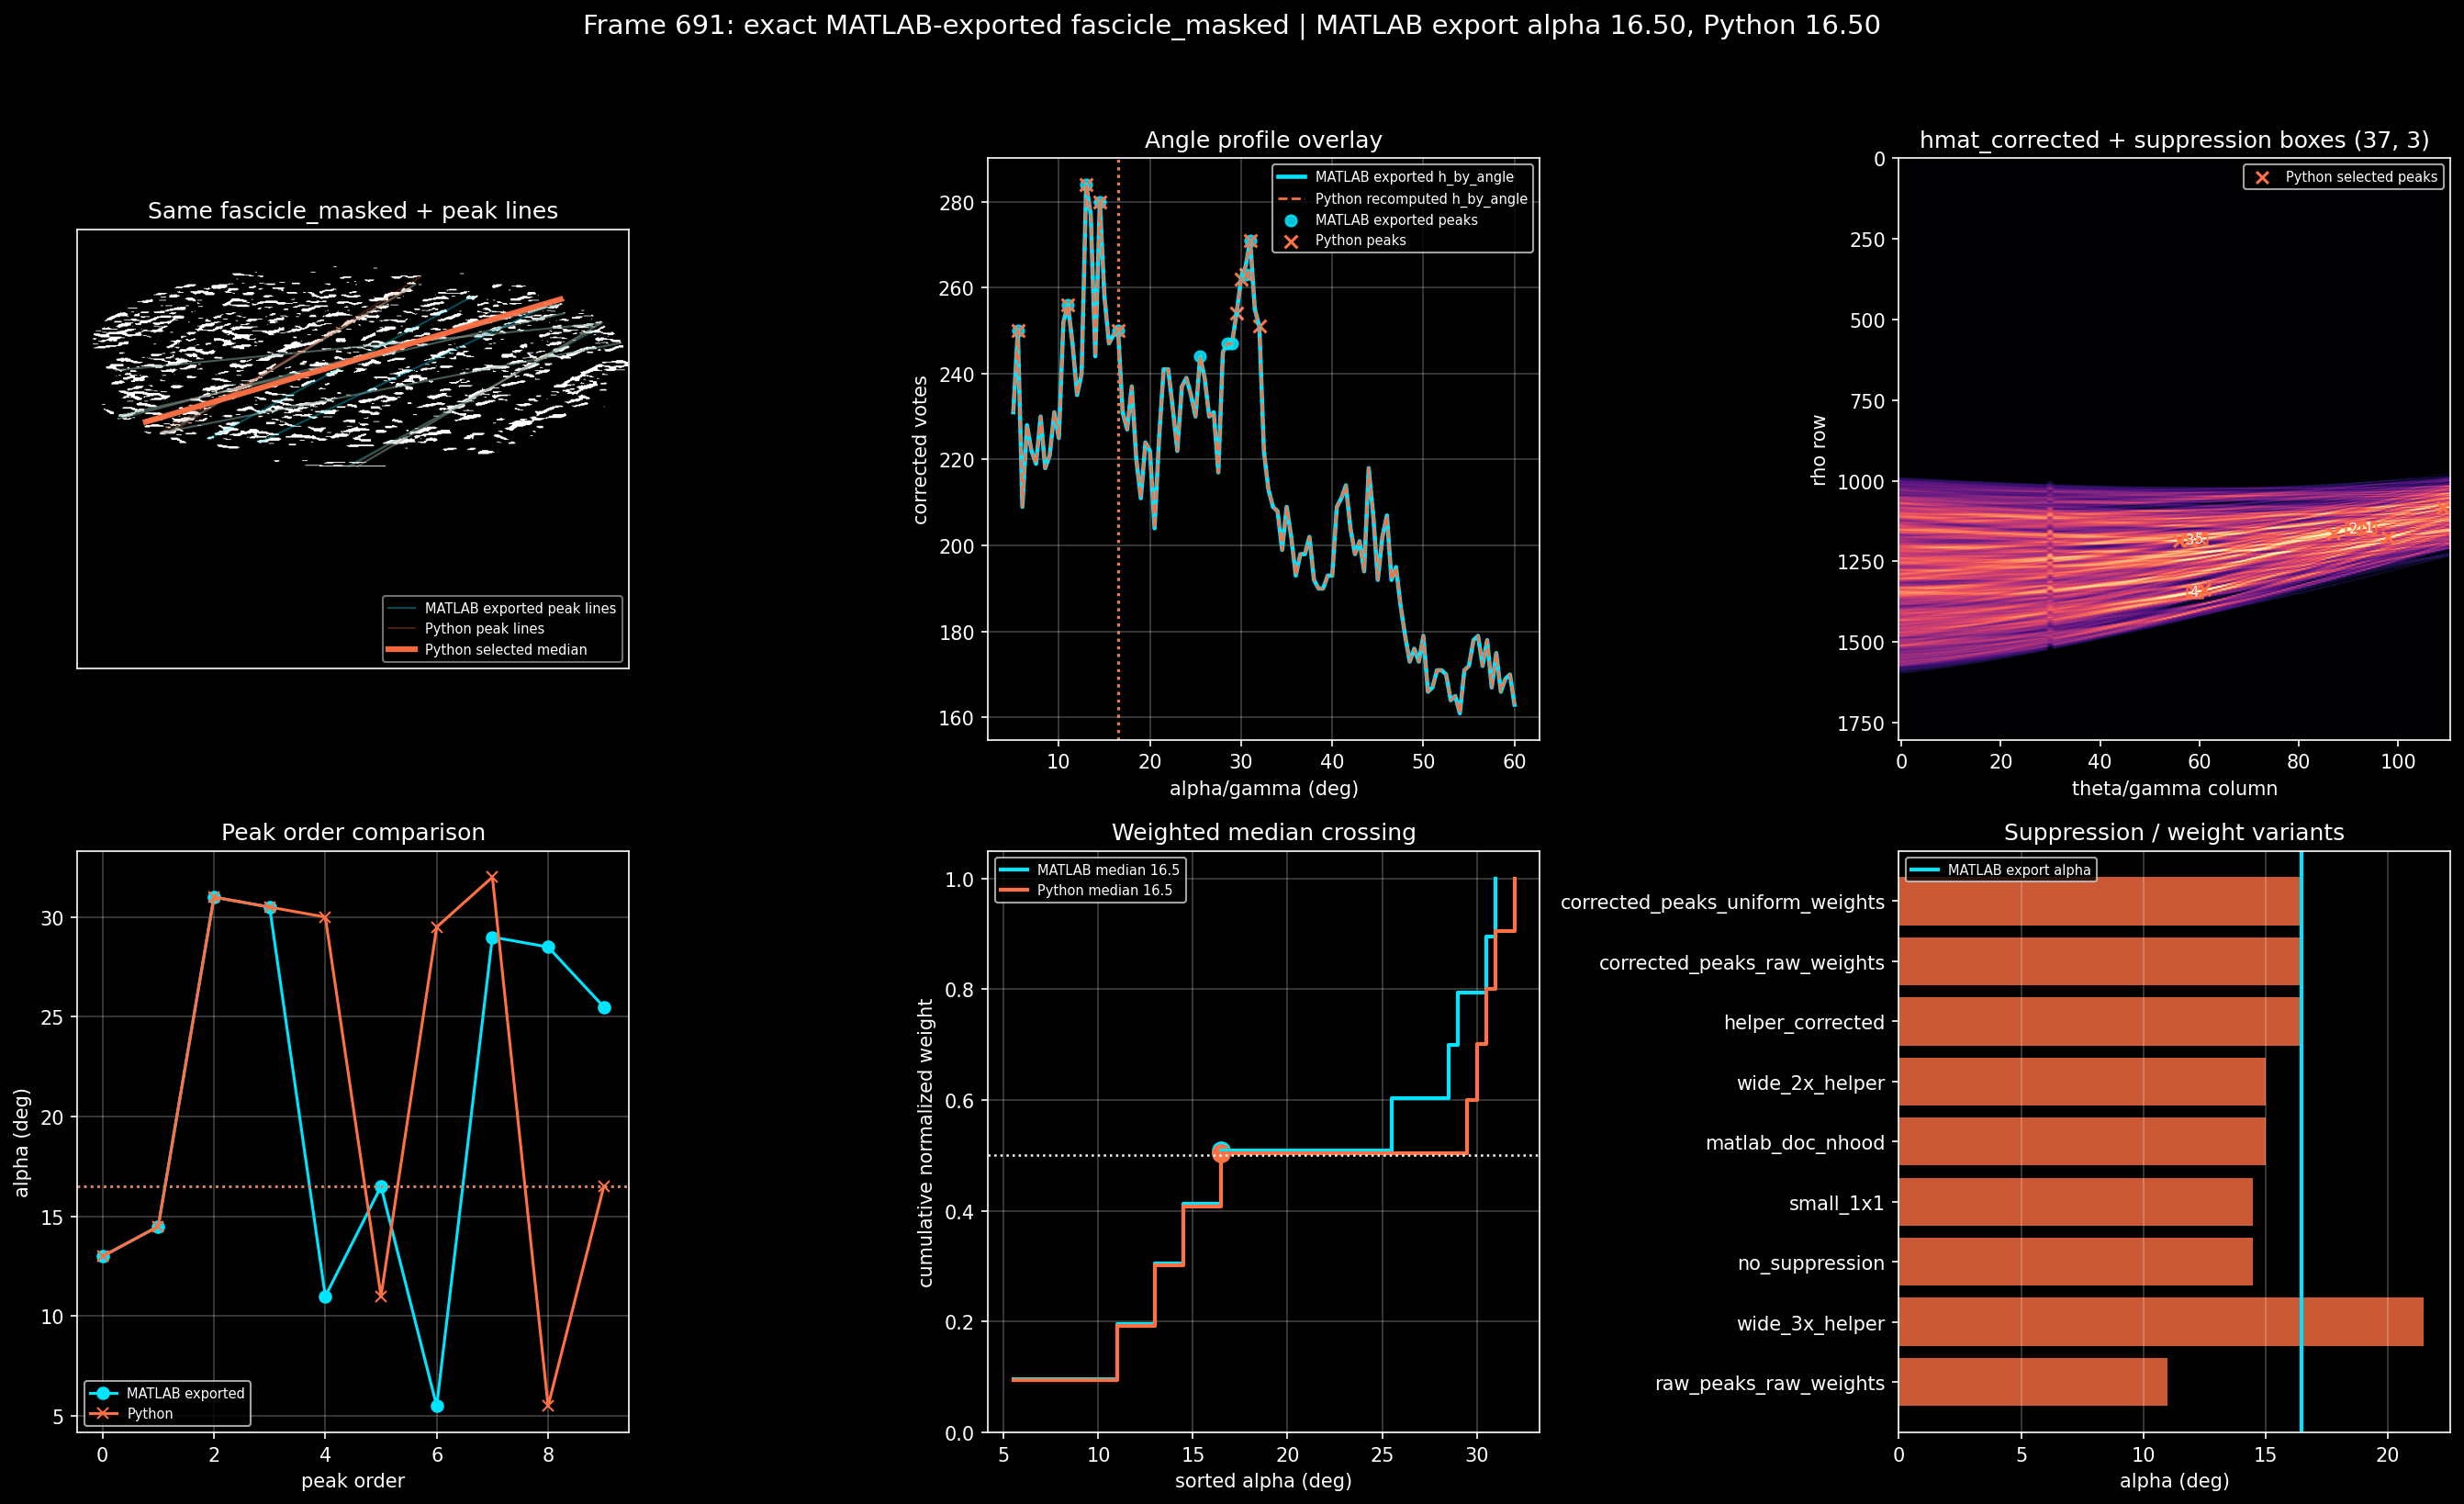

### Frame 0

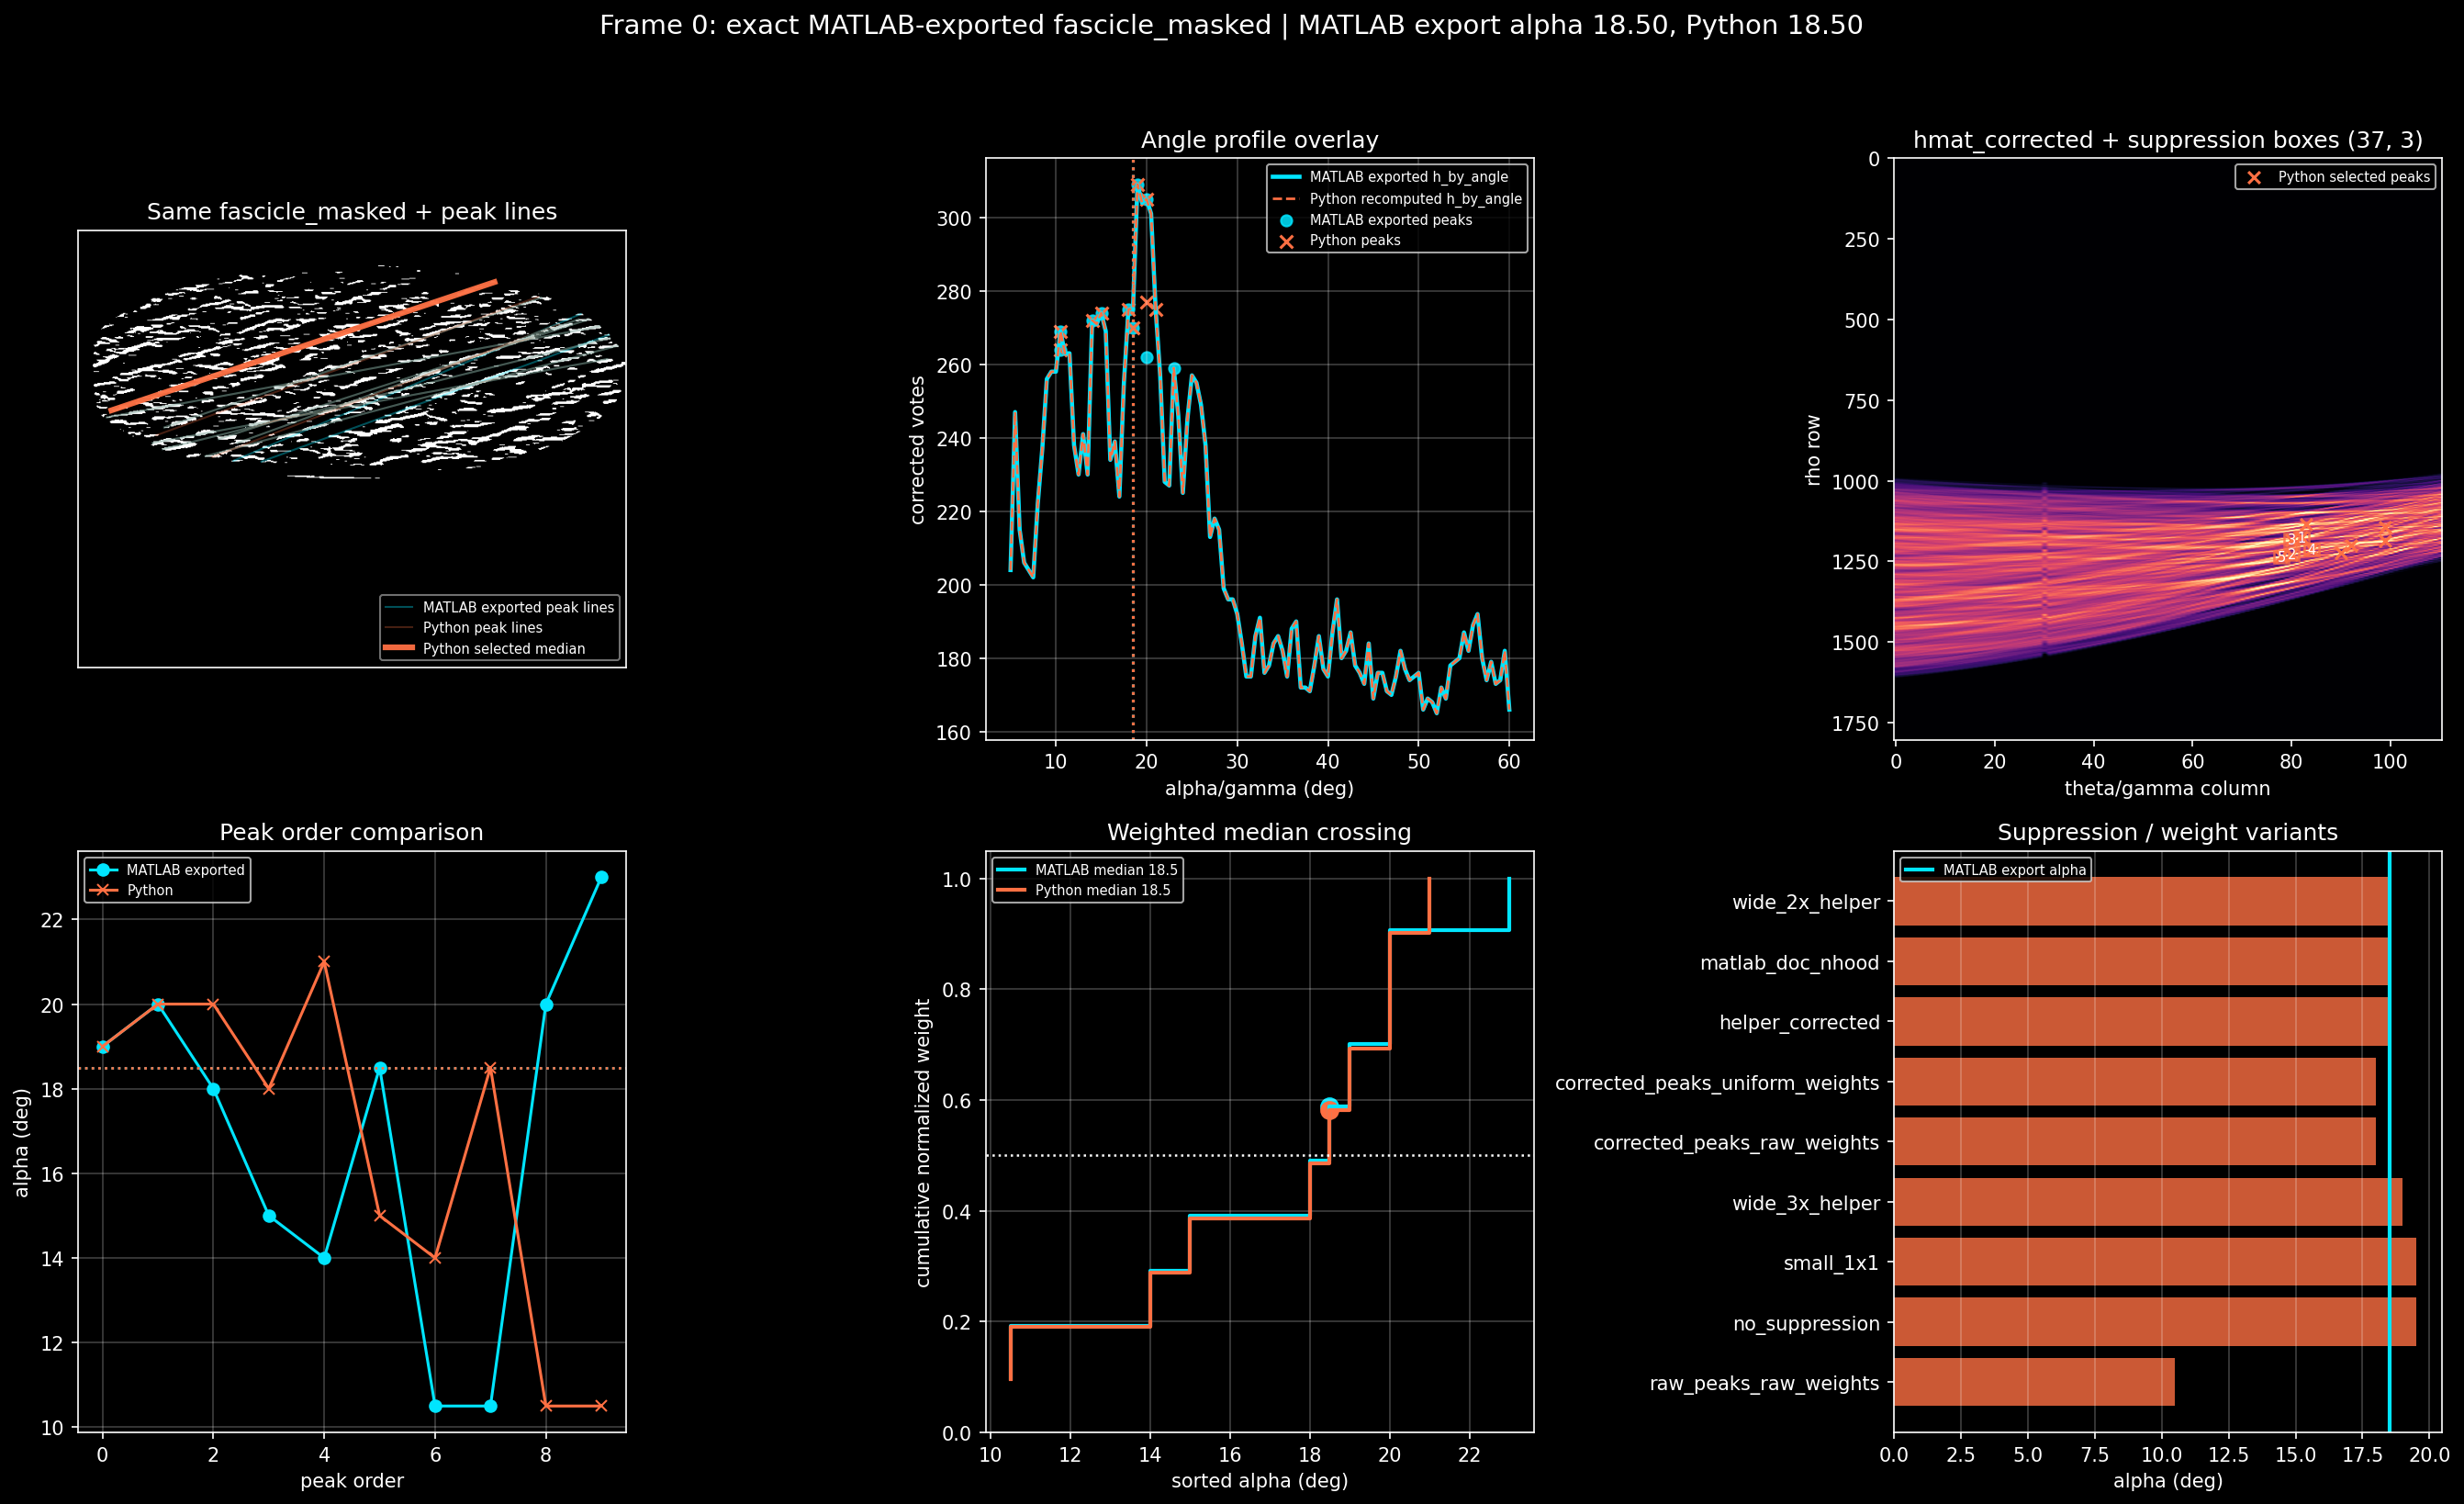

### Frame 1066

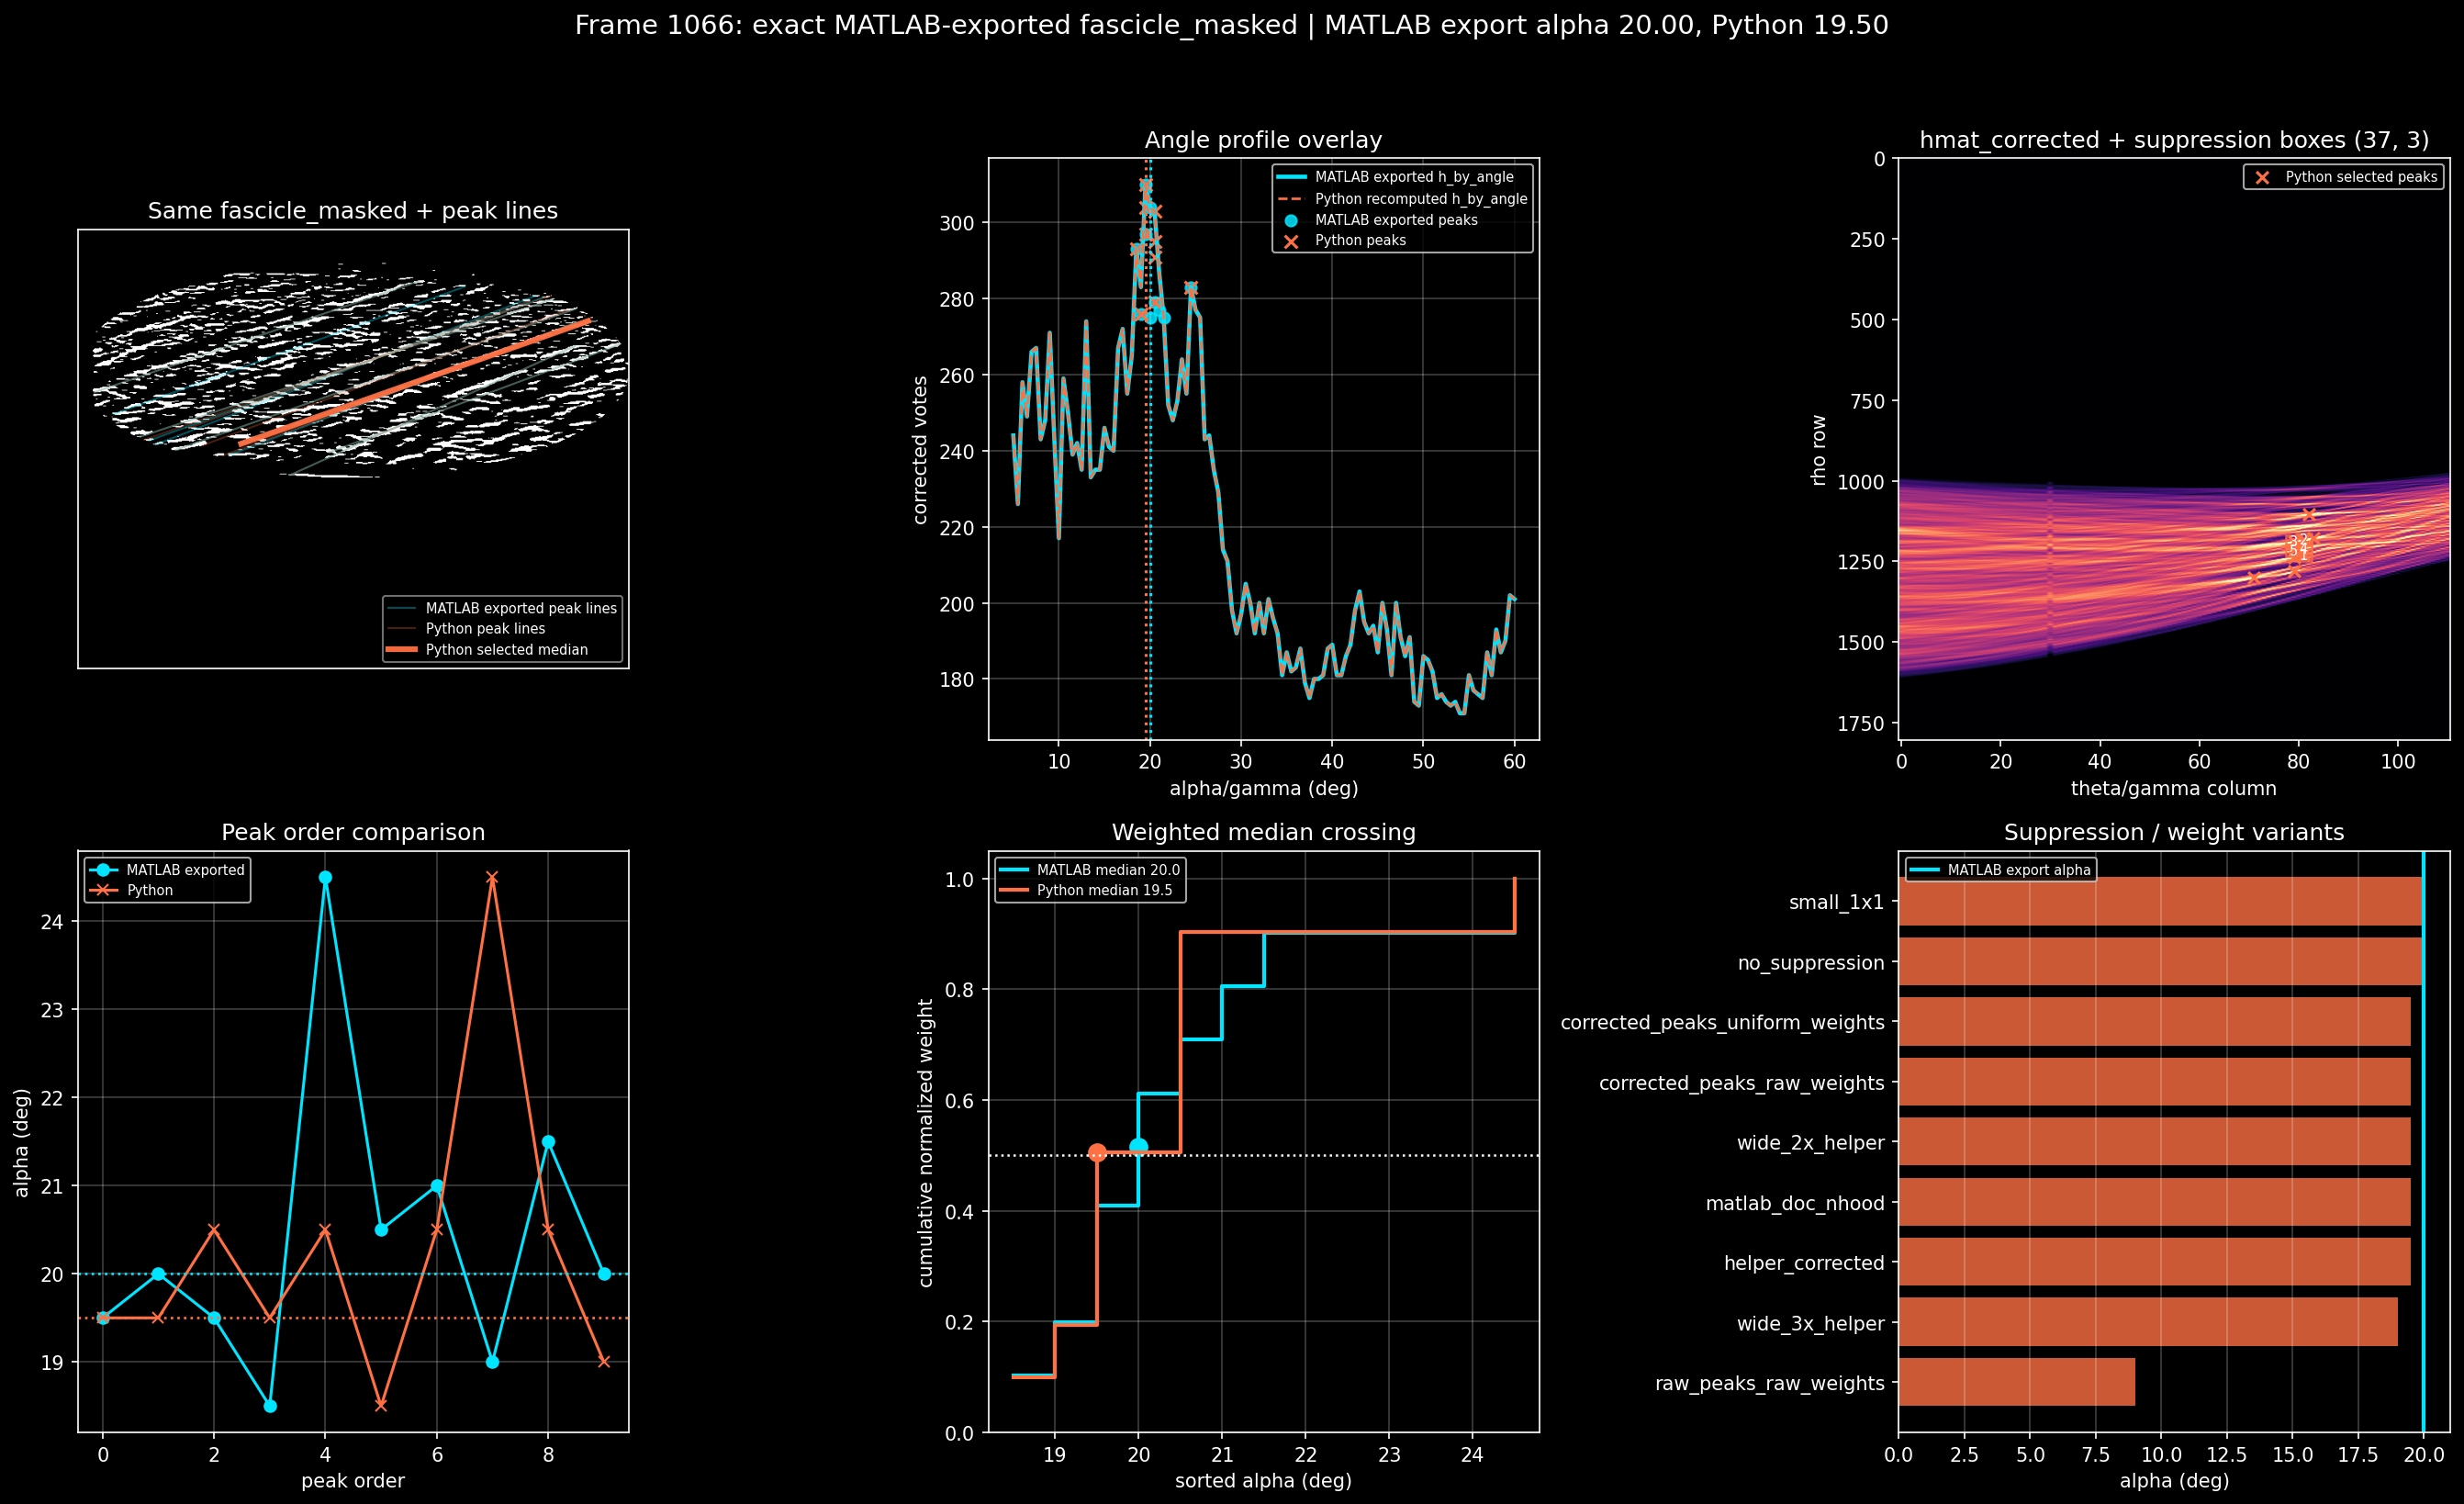

Saved 3 panels in /Users/grosbedou/PycharmProjects/NDORMS/results/notebook40_dohough_same_mask_internals/figures


In [6]:
def sort_by_gamma(gamma, values):
    order = np.argsort(np.asarray(gamma, dtype=float))
    return np.asarray(gamma, dtype=float)[order], np.asarray(values, dtype=float)[order]


def plot_matlab_lines(ax, entry, color="#00e5ff"):
    x = np.asarray(entry["dohough_x"], dtype=float)
    y = np.asarray(entry["dohough_y"], dtype=float)
    if x.ndim != 2 or y.ndim != 2:
        return
    labeled = False
    for i in range(min(len(x), len(y))):
        xs = x[i]
        ys = y[i]
        if len(xs) >= 2 and len(ys) >= 2 and np.all(np.isfinite(xs[:2])) and np.all(np.isfinite(ys[:2])):
            ax.plot(xs[:2] - 1, ys[:2] - 1, color=color, linewidth=1.0, alpha=0.35, label="MATLAB exported peak lines" if not labeled else None)
            labeled = True


def plot_python_lines(ax, binary, core, current, color="#ff7043"):
    labeled = False
    for peak in current["peaks"]:
        xs, ys = line_endpoints_for_peak(binary, core, peak)
        if np.all(np.isfinite(xs)) and np.all(np.isfinite(ys)):
            ax.plot(xs - 1, ys - 1, color=color, linewidth=1.0, alpha=0.28, label="Python peak lines" if not labeled else None)
            labeled = True
    if len(current["alphas"]):
        idx = int(np.nanargmin(np.abs(current["alphas"] - current["alpha"])))
        xs, ys = line_endpoints_for_peak(binary, core, current["peaks"][idx])
        if np.all(np.isfinite(xs)) and np.all(np.isfinite(ys)):
            ax.plot(xs - 1, ys - 1, color=color, linewidth=3.0, alpha=0.95, label="Python selected median")


def add_suppression_rectangles(ax, trace, max_boxes=5):
    import matplotlib.patches as patches
    for item in trace[:max_boxes]:
        rect = patches.Rectangle((item["c0"] - 0.5, item["r0"] - 0.5), item["c1"] - item["c0"], item["r1"] - item["r0"], fill=False, edgecolor="#ff7043", linewidth=1.2, alpha=0.8)
        ax.add_patch(rect)
        ax.text(item["col"], item["row"], str(item["order"] + 1), color="white", fontsize=7, ha="center", va="center")


def plot_frame_dohough_panel(frame_idx):
    dbg = same_mask_debug[int(frame_idx)]
    entry = dbg["entry"]
    binary = dbg["binary"]
    core = dbg["core"]
    current = dbg["current"]
    mat_alphas = dbg["mat_alphas"]
    mat_weights = dbg["mat_weights"]
    mat_alpha = dbg["mat_alpha_saved"]
    mat_a_sorted, mat_w_sorted, mat_cum, mat_sel = dbg["mat_sorted"]
    py_a_sorted, py_w_sorted, py_cum, py_sel = dbg["py_sorted"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f"Frame {frame_idx}: exact MATLAB-exported fascicle_masked | MATLAB export alpha {mat_alpha:.2f}, Python {current['alpha']:.2f}", y=0.99, fontsize=14)

    ax = axes[0, 0]
    ax.imshow(binary, cmap="gray")
    plot_matlab_lines(ax, entry)
    plot_python_lines(ax, binary, core, current)
    ax.set_title("Same fascicle_masked + peak lines")
    ax.legend(loc="lower right", fontsize=7, framealpha=0.55)

    ax = axes[0, 1]
    g_m, h_m = sort_by_gamma(core["gamma"], np.asarray(entry["h_by_angle"], dtype=float))
    g_p, h_p = sort_by_gamma(core["gamma"], core["h_by_angle"])
    ax.plot(g_m, h_m, color="#00e5ff", linewidth=2.2, label="MATLAB exported h_by_angle")
    ax.plot(g_p, h_p, color="#ff7043", linestyle="--", linewidth=1.3, label="Python recomputed h_by_angle")
    ax.scatter(mat_alphas, mat_weights, color="#00e5ff", s=34, alpha=0.85, label="MATLAB exported peaks")
    ax.scatter(current["alphas"], current["weights"], color="#ff7043", marker="x", s=44, label="Python peaks")
    ax.axvline(mat_alpha, color="#00e5ff", linestyle=":", linewidth=1.5)
    ax.axvline(current["alpha"], color="#ff7043", linestyle=":", linewidth=1.5)
    ax.set_xlabel("alpha/gamma (deg)")
    ax.set_ylabel("corrected votes")
    ax.set_title("Angle profile overlay")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7)

    ax = axes[0, 2]
    hcorr = core["hmat_corrected"]
    ax.imshow(hcorr, cmap="magma", aspect="auto", vmin=0, vmax=max(np.nanpercentile(hcorr, 99.8), 1))
    peaks = current["peaks"]
    if len(peaks):
        ax.scatter(peaks[:, 1], peaks[:, 0], color="#ff7043", marker="x", s=38, label="Python selected peaks")
    add_suppression_rectangles(ax, current["trace"], max_boxes=5)
    ax.set_xlabel("theta/gamma column")
    ax.set_ylabel("rho row")
    ax.set_title(f"hmat_corrected + suppression boxes {current['nhood']}")
    ax.legend(fontsize=7)

    ax = axes[1, 0]
    ax.plot(np.arange(len(mat_alphas)), mat_alphas, "o-", color="#00e5ff", label="MATLAB exported")
    ax.plot(np.arange(len(current["alphas"])), current["alphas"], "x-", color="#ff7043", label="Python")
    ax.axhline(mat_alpha, color="#00e5ff", linestyle=":", linewidth=1.3)
    ax.axhline(current["alpha"], color="#ff7043", linestyle=":", linewidth=1.3)
    ax.set_xlabel("peak order")
    ax.set_ylabel("alpha (deg)")
    ax.set_title("Peak order comparison")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7)

    ax = axes[1, 1]
    if len(mat_a_sorted):
        ax.step(mat_a_sorted, mat_cum, where="post", color="#00e5ff", linewidth=2, label=f"MATLAB median {mat_alpha:.1f}")
        if 0 <= mat_sel < len(mat_a_sorted): ax.scatter([mat_a_sorted[mat_sel]], [mat_cum[mat_sel]], color="#00e5ff", s=80)
    if len(py_a_sorted):
        ax.step(py_a_sorted, py_cum, where="post", color="#ff7043", linewidth=2, label=f"Python median {current['alpha']:.1f}")
        if 0 <= py_sel < len(py_a_sorted): ax.scatter([py_a_sorted[py_sel]], [py_cum[py_sel]], color="#ff7043", s=80)
    ax.axhline(0.5, color="white", linestyle=":", linewidth=1.2)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("sorted alpha (deg)")
    ax.set_ylabel("cumulative normalized weight")
    ax.set_title("Weighted median crossing")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7)

    ax = axes[1, 2]
    sub = variant_df.loc[variant_df["frame"] == int(frame_idx)].copy().sort_values("abs_error_to_matlab_export", ascending=False)
    ax.barh(sub["variant"], sub["alpha"], color="#ff7043", alpha=0.8)
    ax.axvline(mat_alpha, color="#00e5ff", linewidth=2, label="MATLAB export alpha")
    ax.set_xlabel("alpha (deg)")
    ax.set_title("Suppression / weight variants")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(fontsize=7)

    axes[0, 0].set_xticks([])
    axes[0, 0].set_yticks([])
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    path = OUT_FIG_DIR / f"frame_{int(frame_idx):06d}_dohough_same_mask_internals.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return path

panel_paths = []
for frame_idx in FOCUS_FRAMES:
    if frame_idx in same_mask_debug:
        path = plot_frame_dohough_panel(frame_idx)
        panel_paths.append(path)
        display(Markdown(f"### Frame {frame_idx}"))
        display(Image(filename=str(path)))
print(f"Saved {len(panel_paths)} panels in {OUT_FIG_DIR}")


## Exact Peak Order Tables For Focus Frames

In [7]:
for frame_idx in FOCUS_FRAMES:
    if frame_idx in EXPORTED_FRAMES:
        display(Markdown(f"### Frame {frame_idx}"))
        display(peak_df.loc[peak_df["frame"] == frame_idx].round(4))
        display(crossing_df.loc[crossing_df["frame"] == frame_idx].round(4))


### Frame 691

,frame,peak_order,matlab_alpha,matlab_weight,python_alpha,python_weight,same_alpha,same_weight
30,691,0,13.0,284.0,13.0,284.0,True,True
31,691,1,14.5,280.0,14.5,280.0,True,True
32,691,2,31.0,271.0,31.0,271.0,True,True
33,691,3,30.5,263.0,30.5,263.0,True,True
34,691,4,11.0,256.0,30.0,262.0,False,False
35,691,5,16.5,250.0,11.0,256.0,False,False
36,691,6,5.5,250.0,29.5,254.0,False,False
37,691,7,29.0,247.0,32.0,251.0,False,False
38,691,8,28.5,247.0,5.5,250.0,False,False
39,691,9,25.5,244.0,16.5,250.0,False,False


,frame,source,sorted_index,alpha,normalized_weight,cumulative_weight,selected
60,691,matlab_export,0,5.5,0.0965,0.0965,False
61,691,matlab_export,1,11.0,0.0988,0.1952,False
62,691,matlab_export,2,13.0,0.1096,0.3048,False
63,691,matlab_export,3,14.5,0.1080,0.4128,False
64,691,matlab_export,4,16.5,0.0965,0.5093,True
65,691,matlab_export,5,25.5,0.0941,0.6034,False
66,691,matlab_export,6,28.5,0.0953,0.6987,False
67,691,matlab_export,7,29.0,0.0953,0.7940,False
68,691,matlab_export,8,30.5,0.1015,0.8954,False
69,691,matlab_export,9,31.0,0.1046,1.0000,False


### Frame 0

,frame,peak_order,matlab_alpha,matlab_weight,python_alpha,python_weight,same_alpha,same_weight
0,0,0,19.0,309.0,19.0,309.0,True,True
1,0,1,20.0,305.0,20.0,305.0,True,True
2,0,2,18.0,275.0,20.0,277.0,False,False
3,0,3,15.0,274.0,18.0,275.0,False,False
4,0,4,14.0,272.0,21.0,275.0,False,False
5,0,5,18.5,270.0,15.0,274.0,False,False
6,0,6,10.5,269.0,14.0,272.0,False,False
7,0,7,10.5,264.0,18.5,270.0,False,False
8,0,8,20.0,262.0,10.5,269.0,False,False
9,0,9,23.0,259.0,10.5,264.0,False,False


,frame,source,sorted_index,alpha,normalized_weight,cumulative_weight,selected
0,0,matlab_export,0,10.5,0.0975,0.0975,False
1,0,matlab_export,1,10.5,0.0957,0.1932,False
2,0,matlab_export,2,14.0,0.0986,0.2918,False
3,0,matlab_export,3,15.0,0.0993,0.3911,False
4,0,matlab_export,4,18.0,0.0997,0.4908,False
5,0,matlab_export,5,18.5,0.0979,0.5886,True
6,0,matlab_export,6,19.0,0.1120,0.7006,False
7,0,matlab_export,7,20.0,0.1105,0.8112,False
8,0,matlab_export,8,20.0,0.0950,0.9061,False
9,0,matlab_export,9,23.0,0.0939,1.0000,False


### Frame 1066

,frame,peak_order,matlab_alpha,matlab_weight,python_alpha,python_weight,same_alpha,same_weight
50,1066,0,19.5,310.0,19.5,310.0,True,True
51,1066,1,20.0,304.0,19.5,304.0,False,True
52,1066,2,19.5,297.0,20.5,303.0,False,False
53,1066,3,18.5,293.0,19.5,297.0,False,False
54,1066,4,24.5,283.0,20.5,295.0,False,False
55,1066,5,20.5,279.0,18.5,293.0,False,False
56,1066,6,21.0,277.0,20.5,291.0,False,False
57,1066,7,19.0,276.0,24.5,283.0,False,False
58,1066,8,21.5,275.0,20.5,279.0,False,False
59,1066,9,20.0,275.0,19.0,276.0,False,False


,frame,source,sorted_index,alpha,normalized_weight,cumulative_weight,selected
100,1066,matlab_export,0,18.5,0.1021,0.1021,False
101,1066,matlab_export,1,19.0,0.0962,0.1983,False
102,1066,matlab_export,2,19.5,0.1081,0.3064,False
103,1066,matlab_export,3,19.5,0.1035,0.4099,False
104,1066,matlab_export,4,20.0,0.1060,0.5159,True
105,1066,matlab_export,5,20.0,0.0959,0.6117,False
106,1066,matlab_export,6,20.5,0.0972,0.7090,False
107,1066,matlab_export,7,21.0,0.0965,0.8055,False
108,1066,matlab_export,8,21.5,0.0959,0.9014,False
109,1066,matlab_export,9,24.5,0.0986,1.0000,False


## What This Means For The Suspicious Frames

Frames `2533` and `1722` are not in the Notebook 36 MATLAB mask export, so this notebook cannot do a strict same-mask comparison for them yet. The correct next MATLAB export should include those frames if we want to know whether their problem is upstream mask generation or downstream `dohough`.

In [8]:
requested_rows = []
for frame_idx in REQUESTED_SUSPICIOUS_FRAMES:
    requested_rows.append({
        "frame": frame_idx,
        "same_mask_export_available": frame_idx in EXPORTED_FRAMES,
        "current_slow_low_2_geofeatures_alpha": float(current_geo["alpha_deg"][frame_idx]) if frame_idx < len(current_geo["alpha_deg"]) else np.nan,
        "notebook36_export_alpha_if_available": float(np.asarray(mask_by_frame[frame_idx]["alpha"], dtype=float).reshape(-1)[0]) if frame_idx in mask_by_frame else np.nan,
    })
requested_df = pd.DataFrame(requested_rows)
display(requested_df.round(4))

matlab_export_lines = [
    "% Add these frames to the MATLAB intermediate-mask export, then rerun Notebook 40.",
    "frames0 = [2533 1722 691 0];       % zero-based Python frame numbers",
    "frames1 = frames0 + 1;             % MATLAB frame numbers if your loop is one-based",
    "",
    "% In the same workspace/GUI state used to produce slow_low_2.mat, export for each frame:",
    "% apo_thres, apo_super, apo_deep, fas_filt, fas_thres_raw, fas_thres,",
    "% Emask, fascicle_masked, super_vec, deep_vec,",
    "% alphas, weights/ws, h_by_angle, dohough_x, dohough_y, alpha, Emask_radius.",
    "% Save to results/notebook40_dohough_same_mask_internals/current_matlab_masks_for_dohough.mat",
]
print(chr(10).join(matlab_export_lines))

missing = [f for f in REQUESTED_SUSPICIOUS_FRAMES if f not in EXPORTED_FRAMES]
if missing:
    display(Markdown("**Need from MATLAB for complete diagnosis:** export current-run intermediate masks for frames " + ", ".join(map(str, missing)) + "."))

,frame,same_mask_export_available,current_slow_low_2_geofeatures_alpha,notebook36_export_alpha_if_available
0,2533,False,39.5,NaN
1,1722,False,33.5,NaN
2,691,True,34.0,16.5
3,0,True,18.5,18.5


% Add these frames to the MATLAB intermediate-mask export, then rerun Notebook 40.
frames0 = [2533 1722 691 0];       % zero-based Python frame numbers
frames1 = frames0 + 1;             % MATLAB frame numbers if your loop is one-based

% In the same workspace/GUI state used to produce slow_low_2.mat, export for each frame:
% apo_thres, apo_super, apo_deep, fas_filt, fas_thres_raw, fas_thres,
% Emask, fascicle_masked, super_vec, deep_vec,
% alphas, weights/ws, h_by_angle, dohough_x, dohough_y, alpha, Emask_radius.
% Save to results/notebook40_dohough_same_mask_internals/current_matlab_masks_for_dohough.mat


**Need from MATLAB for complete diagnosis:** export current-run intermediate masks for frames 2533, 1722.

## Notebook 40 First Verdict

Read this after execution:

- If `h_by_angle_exact_equal` is `True`, Python's accumulator, diagonal-bias replacement, ellipse correction, and angle profile match MATLAB for that exported mask.
- If peak order differs while `h_by_angle` is identical, the remaining difference is `houghpeaks` local maximum ordering, tie handling, or suppression neighborhood.
- If exported-mask alpha and current `slow_low_2.mat` alpha differ for the same frame, then the MATLAB export and current `.mat` were not generated from the same intermediate mask state. In that case, export the current-run masks for the suspicious frames before changing Python code.